# Flood Area Segmentation Notebook
**Dataset:** `faizalkarim/flood-area-segmentation` (Kaggle)

This notebook applies **classical image segmentation** to flood images and uses
**metadata** to adapt the segmentation parameters per image for better results.

### What you will learn
- How to download a Kaggle dataset and force-refresh it in Google Drive
- How to load and use a metadata CSV to improve segmentation
- How to segment flood regions using adaptive thresholding + morphology
- How to evaluate and compare results grouped by metadata categories


## Step 1: Install packages

In [ ]:
# Uncomment in Google Colab if needed
# !pip install -q kagglehub

## Step 2: Import libraries

In [1]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"]    = "gray"


## Step 3: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Step 4: Download dataset and force-refresh in Google Drive
> **Why force-refresh?**  
> If the folder already exists from a previous run, the old dataset stays on disk
> and your code keeps reading stale images. `shutil.rmtree` removes it first so
> you always get a clean copy of the current dataset.


In [3]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("faizalkarim/flood-area-segmentation")
)
print("Downloaded to:", DOWNLOAD_DIR)

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/simple_segmentation_training")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

# Always wipe and re-copy so we never read stale data
if DATASET_DIR.exists():
    shutil.rmtree(DATASET_DIR)
    print("Removed old dataset folder.")

shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
print("Copied fresh dataset to Drive:", DATASET_DIR)


100%|██████████| 107M/107M [00:00<00:00, 161MB/s] 

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1
Removed old dataset folder.
Copied fresh dataset to Drive: /content/drive/MyDrive/simple_segmentation_training/dataset


## Step 5: Inspect dataset structure

In [4]:
for root, dirs, files in os.walk(DATASET_DIR):
    level  = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:5]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue


dataset/
  metadata.csv
  Image/
    2010.jpg
    1005.jpg
    2031.jpg
    3040.jpg
    1063.jpg
  Mask/
    49.png
    1063.png
    3014.png
    3083.png
    3001.png


## Step 6: Load metadata CSV
The metadata CSV tells us extra information about each image — such as whether
flooding is heavy or light. We will use this later to pick better segmentation
parameters per image.


In [5]:
metadata_path = DATASET_DIR / "metadata.csv"
df_meta = pd.read_csv(metadata_path)

print("Metadata shape:", df_meta.shape)
print("\nColumns:", df_meta.columns.tolist())
print()
df_meta.head(10)


Metadata shape: (290, 2)

Columns: ['Image', 'Mask']



,Image,Mask
0,0.jpg,0.png
1,1.jpg,1.png
2,2.jpg,2.png
3,3.jpg,3.png
4,4.jpg,4.png
5,5.jpg,5.png
6,6.jpg,6.png
7,7.jpg,7.png
8,8.jpg,8.png
9,9.jpg,9.png


## Step 7: Understand the metadata
Run this cell to see what values each metadata column contains.  
We will use these values to tune our segmentation.


In [6]:
for col in df_meta.columns:
    unique_vals = df_meta[col].unique()
    print(f"{col:30s} — {len(unique_vals)} unique values:", unique_vals[:10])


Image                          — 290 unique values: ['0.jpg' '1.jpg' '2.jpg' '3.jpg' '4.jpg' '5.jpg' '6.jpg' '7.jpg' '8.jpg'
 '9.jpg']
Mask                           — 290 unique values: ['0.png' '1.png' '2.png' '3.png' '4.png' '5.png' '6.png' '7.png' '8.png'
 '9.png']


## Step 8: Find image and mask folders automatically

In [7]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates  = []

for d in all_dirs:
    name    = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue
    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print(" -", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print(" -", d, "|", n)


Image candidates:
 - /content/drive/MyDrive/simple_segmentation_training/dataset/Image | 290

Mask candidates:
 - /content/drive/MyDrive/simple_segmentation_training/dataset/Mask | 290


## Step 9: Select the best folders

In [8]:
IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR  = sorted(mask_candidates,  key=lambda x: x[1], reverse=True)[0][0]

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)


IMAGE_DIR: /content/drive/MyDrive/simple_segmentation_training/dataset/Image
MASK_DIR : /content/drive/MyDrive/simple_segmentation_training/dataset/Mask


## Step 10: Helper functions

In [9]:
def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(
        image[mask_bool], 1 - alpha,
        color_layer[mask_bool], alpha, 0
    )
    return out


## Step 11: Build image-mask pairs and join with metadata

In [10]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)
    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files  = list_image_files(mask_dir)

    mask_map = {extract_id(m.name): m for m in mask_files}

    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))
    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found :", len(list_image_files(IMAGE_DIR)))
print("Masks  found :", len(list_image_files(MASK_DIR)))
print("Pairs  found :", len(pairs))

# ── Join pairs with metadata ──────────────────────────────────────────────
# Build a lookup: filename stem → metadata row
# Adjust 'image_id' below if your metadata uses a different column name
ID_COL = df_meta.columns[0]          # usually 'image_id' or similar
meta_lookup = {
    Path(str(v)).stem: df_meta.iloc[i]
    for i, v in enumerate(df_meta[ID_COL])
}

enriched_pairs = []
for img_path, mask_path in pairs:
    stem = img_path.stem
    meta = meta_lookup.get(stem, None)
    enriched_pairs.append((img_path, mask_path, meta))

has_meta = sum(1 for _, _, m in enriched_pairs if m is not None)
print(f"Pairs with metadata: {has_meta} / {len(enriched_pairs)}")


Images found : 290
Masks  found : 290
Pairs  found : 290
Pairs with metadata: 290 / 290


## Step 12: Preview one image and its mask

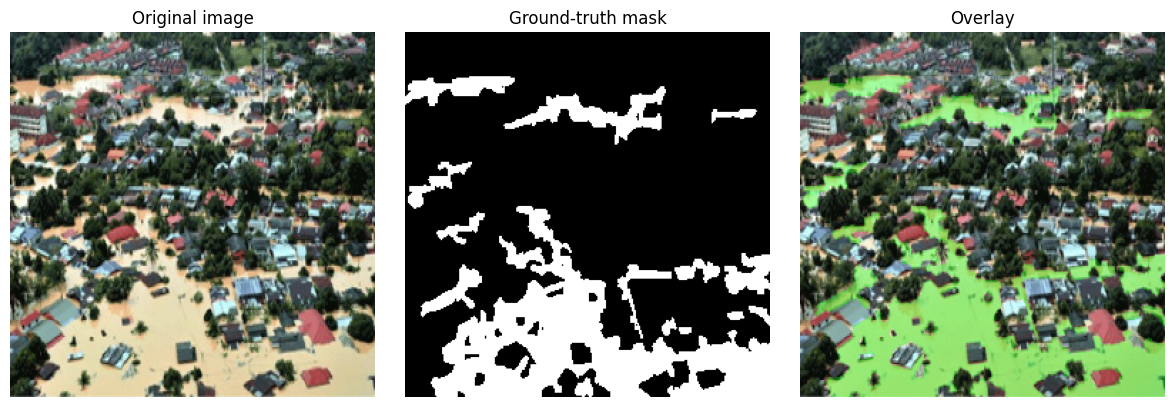

Image: 0.jpg
Mask : 0.png

Metadata for this image:
Image    0.jpg
Mask     0.png


In [11]:
if len(enriched_pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path, sample_meta = enriched_pairs[0]

img  = read_image(img_path)
gt   = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original image", "Ground-truth mask", "Overlay"],
    cols=3, size=(12, 4)
)

print("Image:", img_path.name)
print("Mask :", mask_path.name)
if sample_meta is not None:
    print("\nMetadata for this image:")
    print(sample_meta.to_string())


# Metadata-Guided Segmentation

## Idea
Instead of using the same fixed threshold for every image, we read the metadata
and choose better parameters automatically:

| Metadata hint | What we change |
|---|---|
| **Flood level = heavy** | lower threshold (more of the image is water → cast a wider net) |
| **Flood level = light** | higher threshold (only the brightest water patches) |
| **No metadata** | fall back to Otsu thresholding (automatic) |

This is how metadata improves classical segmentation **without deep learning**.


## Step 13: Metadata-guided segmentation function

In [12]:
def get_threshold_from_meta(meta):
    """
    Return a fixed threshold (0-255) based on metadata, or None to use Otsu.

    *** IMPORTANT — read your metadata columns first (Step 7) ***
    Then update the column name and value checks below to match your CSV.

    Example column names you might see: 'flood_type', 'water_level',
    'severity', 'label', 'class', 'condition', etc.
    """
    if meta is None:
        return None   # no metadata → use Otsu

    # ── Edit this block to match your actual column names ─────────────────
    # Try common column names; the first one found wins.
    for col in ["flood_type", "water_level", "severity", "label", "class", "condition"]:
        if col not in meta.index:
            continue
        val = str(meta[col]).strip().lower()

        if val in ["heavy", "high", "severe", "flooded", "1", "true", "yes"]:
            return 80    # low threshold → detect more water pixels

        if val in ["light", "low", "mild", "partial", "0", "false", "no"]:
            return 160   # high threshold → only the obvious water patches

        # Numeric value (e.g. water level in cm)
        try:
            num = float(val)
            if num > 50:
                return 80
            elif num > 20:
                return 120
            else:
                return 160
        except ValueError:
            pass

    return None   # column found but value unrecognised → use Otsu


def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary
    areas       = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)
    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out


def segment_with_meta(image, meta=None):
    """
    Classical segmentation that adapts its threshold using metadata.
    Returns (gray, blur, predicted_mask, method_used).
    """
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = get_threshold_from_meta(meta)

    if thresh is None:
        # Otsu: automatic threshold, no metadata needed
        _, mask = cv2.threshold(blur, 0, 255,
                                cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
        method = "Otsu (automatic)"
    else:
        # Fixed threshold guided by metadata
        _, mask = cv2.threshold(blur, thresh, 255, cv2.THRESH_BINARY_INV)
        method = f"Metadata-guided (thresh={thresh})"

    kernel = np.ones((5, 5), np.uint8)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask   = largest_component(mask)

    return gray, blur, mask, method


## Step 14: Apply metadata-guided segmentation to one image

Method used: Otsu (automatic)
Metadata:
 Image    0.jpg
Mask     0.png


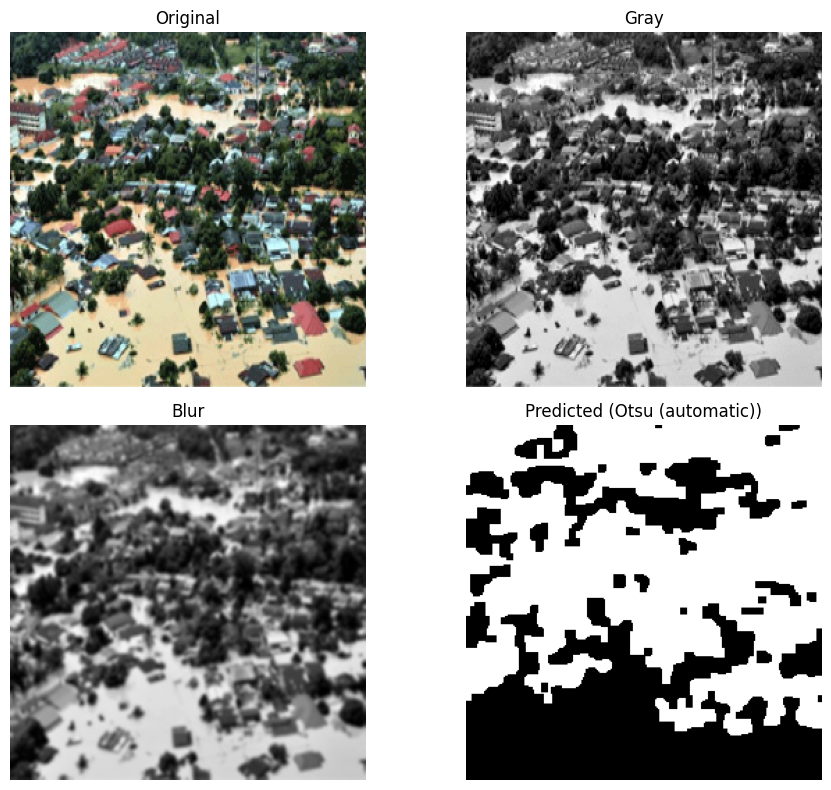

In [13]:
img_path, mask_path, meta = enriched_pairs[0]

img  = read_image(img_path)
gt   = read_mask(mask_path)
gray, blur, pred, method = segment_with_meta(img, meta)

print("Method used:", method)
if meta is not None:
    print("Metadata:\n", meta.to_string())

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", f"Predicted ({method})"],
    cols=2, size=(10, 8)
)


## Step 15: Compare ground truth vs. prediction

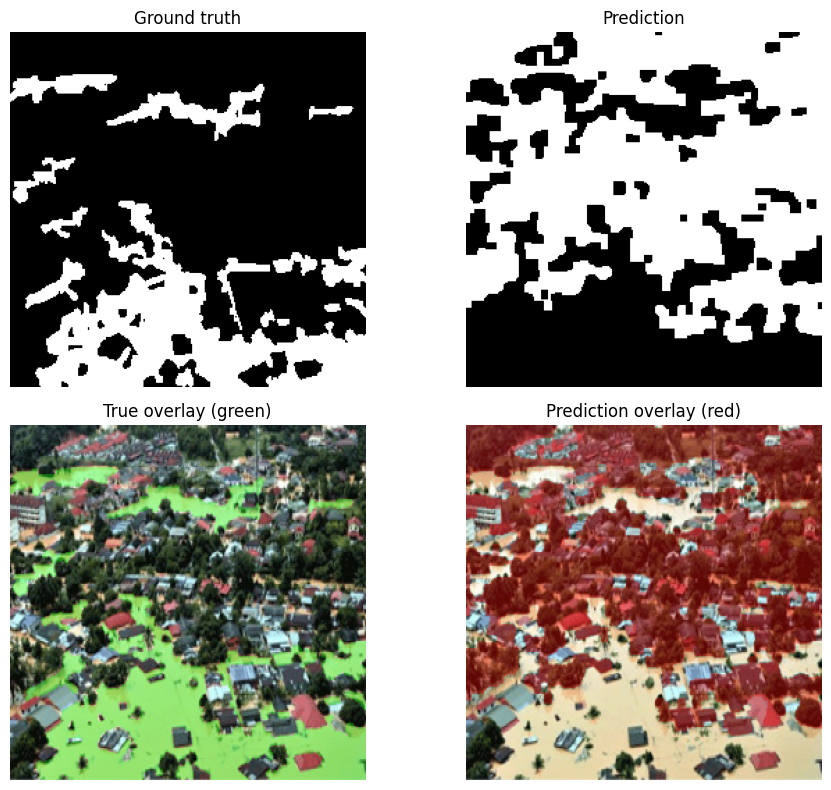

In [14]:
show_many(
    [gt, pred,
     overlay_mask(img, gt,   color=(0, 255, 0)),
     overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction",
     "True overlay (green)", "Prediction overlay (red)"],
    cols=2, size=(10, 8)
)


## Step 16: Metrics functions

In [15]:
def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy  = (tp + tn)         / (tp + tn + fp + fn + 1e-8)
    precision = tp                 / (tp + fp          + 1e-8)
    recall    = tp                 / (tp + fn          + 1e-8)
    f1        = 2*precision*recall / (precision+recall + 1e-8)
    iou       = tp                 / (tp + fp + fn     + 1e-8)
    dice      = 2*tp               / (2*tp + fp + fn   + 1e-8)

    return dict(accuracy=accuracy, precision=precision, recall=recall,
                f1_score=f1, iou=iou, dice=dice)


## Step 17: Evaluate on multiple images

In [16]:
results = []

for img_path, mask_path, meta in enriched_pairs[:50]:
    img         = read_image(img_path)
    gt          = read_mask(mask_path)
    _, _, pred, method = segment_with_meta(img, meta)

    m   = segmentation_metrics(gt, pred)
    row = {"image": img_path.name, "method": method}

    # Add all metadata columns to the results row for later analysis
    if meta is not None:
        for col in df_meta.columns:
            if col in meta.index:
                row[f"meta_{col}"] = meta[col]

    row.update(m)
    results.append(row)

df_results = pd.DataFrame(results)
print(f"Evaluated {len(df_results)} images")
df_results.head()


Evaluated 50 images


,image,method,meta_Image,meta_Mask,accuracy,precision,recall,f1_score,iou,dice
0,0.jpg,Otsu (automatic),0.jpg,0.png,0.208160,0.023029,0.052467,0.032009,0.016265,0.032009
1,1.jpg,Otsu (automatic),1.jpg,1.png,0.131302,0.027727,0.072175,0.040063,0.020441,0.040063
2,10.jpg,Otsu (automatic),10.jpg,10.png,0.524490,0.383838,0.991016,0.553353,0.382507,0.553353
3,1000.jpg,Otsu (automatic),1000.jpg,1000.png,0.501526,0.094639,0.032726,0.048634,0.024923,0.048634
4,1001.jpg,Otsu (automatic),1001.jpg,1001.png,0.275192,0.213864,0.217045,0.215443,0.120726,0.215443


## Step 18: Average results — all images

In [17]:
summary = df_results.mean(numeric_only=True)
print("=== Overall average metrics ===")
print(summary.to_string())


=== Overall average metrics ===
accuracy     0.357791
precision    0.178681
recall       0.205658
f1_score     0.158765
iou          0.099239
dice         0.158765


## Step 19: Compare results grouped by metadata
This is the key benefit of using metadata: we can see **which image categories
are harder to segment** and whether our parameter choices helped.


In [18]:
# Find metadata columns in the results dataframe
meta_cols = [c for c in df_results.columns if c.startswith("meta_")]

if meta_cols:
    for col in meta_cols:
        print(f"\n=== Grouped by: {col} ===")
        grouped = df_results.groupby(col)[["iou", "dice", "f1_score"]].mean()
        print(grouped.to_string())
else:
    print("No metadata columns joined — check ID_COL in Step 11.")



=== Grouped by: meta_Image ===
                 iou      dice  f1_score
meta_Image                              
0.jpg       0.016265  0.032009  0.032009
1.jpg       0.020441  0.040063  0.040063
10.jpg      0.382507  0.553353  0.553353
1000.jpg    0.024923  0.048634  0.048634
1001.jpg    0.120726  0.215443  0.215443
1002.jpg    0.347955  0.516271  0.516271
1003.jpg    0.024791  0.048382  0.048382
1004.jpg    0.004917  0.009786  0.009786
1005.jpg    0.013206  0.026068  0.026068
1006.jpg    0.015110  0.029771  0.029771
1007.jpg    0.084083  0.155123  0.155123
1008.jpg    0.021468  0.042034  0.042034
1009.jpg    0.050493  0.096132  0.096132
1010.jpg    0.099535  0.181049  0.181049
1011.jpg    0.002782  0.005548  0.005548
1012.jpg    0.069310  0.129635  0.129635
1013.jpg    0.005735  0.011405  0.011405
1014.jpg    0.319093  0.483807  0.483807
1015.jpg    0.017781  0.034940  0.034940
1016.jpg    0.000548  0.001096  0.001096
1017.jpg    0.001226  0.002449  0.002449
1018.jpg    0.090175  0.1

## Step 20: Compare metadata-guided vs. Otsu (baseline)

In [19]:
# Run baseline (Otsu only, no metadata) on the same images
baseline_results = []

for img_path, mask_path, _ in enriched_pairs[:50]:
    img         = read_image(img_path)
    gt          = read_mask(mask_path)
    _, _, pred, _ = segment_with_meta(img, meta=None)   # force Otsu

    m   = segmentation_metrics(gt, pred)
    row = {"image": img_path.name}
    row.update(m)
    baseline_results.append(row)

df_baseline = pd.DataFrame(baseline_results)

metric_cols = ["accuracy", "precision", "recall", "f1_score", "iou", "dice"]

comparison = pd.DataFrame({
    "Baseline (Otsu)":   df_baseline[metric_cols].mean(),
    "Metadata-guided":   df_results[metric_cols].mean(),
})
comparison["improvement"] = comparison["Metadata-guided"] - comparison["Baseline (Otsu)"]
print("=== Baseline vs. Metadata-guided ===")
print(comparison.round(4).to_string())


=== Baseline vs. Metadata-guided ===
           Baseline (Otsu)  Metadata-guided  improvement
accuracy            0.3578           0.3578          0.0
precision           0.1787           0.1787          0.0
recall              0.2057           0.2057          0.0
f1_score            0.1588           0.1588          0.0
iou                 0.0992           0.0992          0.0
dice                0.1588           0.1588          0.0


## Step 21: Save results to Google Drive

In [20]:
RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df_results.to_csv(RESULTS_DIR / "segmentation_results_with_meta.csv",  index=False)
df_baseline.to_csv(RESULTS_DIR / "segmentation_results_baseline.csv",  index=False)
comparison.to_csv(RESULTS_DIR / "comparison_meta_vs_baseline.csv")

print("Saved to:", RESULTS_DIR)


Saved to: /content/drive/MyDrive/simple_segmentation_training/results
